In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms
from transformers import (
    SegformerImageProcessor, 
    SegformerForSemanticSegmentation, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
import segmentation_models_pytorch as smp

class Config:
    def __init__(self, active_model, learning_rate, train_batch_size=8, eval_batch_size=8):
        self.IMAGE_DIR = "./data/train/images"
        self.MASK_DIR = "./data/train/masks"
        
        self.K_FOLDS = 5
        self.NUM_CLASSES = 2
        self.ID2LABEL = {0: "background", 1: "filth"}
        self.LABEL2ID = {v: k for k, v in self.ID2LABEL.items()}
        self.DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        self.INCLUDED_FILTH_TYPES = ["meat", "vegetables"] 
        self.INCLUDE_CLEAN_DATA = True 
        
        self.ACTIVE_MODEL = active_model 
        self.LEARNING_RATE = learning_rate
        self.TRAIN_BATCH_SIZE = train_batch_size
        self.EVAL_BATCH_SIZE = eval_batch_size
        self.EPOCHS = 50
        self.PATIENCE = 5

class SegmentationDataset(Dataset):
    def __init__(self, filenames, img_dir, mask_dir, preprocessor):
        self.filenames = filenames
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.preprocessor = preprocessor

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        image = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        
        mask_name = os.path.splitext(fname)[0] + ".png"
        mask = Image.open(os.path.join(self.mask_dir, mask_name)).convert("L")

        mask_array = np.array(mask)
        mask_array[mask_array > 0] = 1
        mask = Image.fromarray(mask_array)

        if isinstance(self.preprocessor, SegformerImageProcessor):
            encoded = self.preprocessor(image, mask, return_tensors="pt")
            for k, v in encoded.items():
                encoded[k] = v.squeeze(0)
            return encoded
        else:
            image_tensor = self.preprocessor(image)
            mask_tensor = torch.from_numpy(np.array(mask.resize((512, 512), Image.NEAREST))).long()
            return {"pixel_values": image_tensor, "labels": mask_tensor}

class SMPWrapperForHuggingFace(nn.Module):
    def __init__(self, model_type, num_classes):
        super().__init__()
        encoder = "resnet34"
        if model_type == "unet":
            self.model = smp.Unet(encoder_name=encoder, encoder_weights="imagenet", in_channels=3, classes=num_classes)
        elif model_type == "deeplabv3":
            self.model = smp.DeepLabV3(encoder_name=encoder, encoder_weights="imagenet", in_channels=3, classes=num_classes)
            
        self.loss_fct = nn.CrossEntropyLoss()

    def forward(self, pixel_values, labels=None, **kwargs):
        logits = self.model(pixel_values)
        loss = None
        if labels is not None:
            loss = self.loss_fct(logits, labels)
        return {"loss": loss, "logits": logits}

class ModelFactory:
    @staticmethod
    def get_model_and_preprocessor(cfg):
        if cfg.ACTIVE_MODEL == "segformer":
            processor = SegformerImageProcessor.from_pretrained("nvidia/mit-b0")
            processor.do_reduce_labels = False
            model = SegformerForSemanticSegmentation.from_pretrained(
                "nvidia/mit-b0",
                num_labels=cfg.NUM_CLASSES,
                id2label=cfg.ID2LABEL,
                label2id=cfg.LABEL2ID,
                ignore_mismatched_sizes=True
            )
            return model, processor
            
        elif cfg.ACTIVE_MODEL in ["unet", "deeplabv3"]:
            processor = transforms.Compose([
                transforms.Resize((512, 512)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
            model = SMPWrapperForHuggingFace(cfg.ACTIVE_MODEL, cfg.NUM_CLASSES)
            return model, processor
        else:
            raise ValueError(f"Unknown model type: {cfg.ACTIVE_MODEL}")

class SegmentationExperiment:
    def __init__(self, config):
        self.cfg = config
        self.all_filenames = []
        self.strat_labels = [] 
        self._prepare_dataset()

    def _prepare_dataset(self):
        raw_files = sorted([
            f for f in os.listdir(self.cfg.IMAGE_DIR) 
            if f.lower().endswith(('.jpg', '.png', '.jpeg'))
        ])
        
        counts = {"meat": 0, "vegetables": 0, "clean": 0, "ignored": 0}

        for fname in raw_files:
            category = fname.split('-')[0].lower()
            
            if category == "clean":
                if self.cfg.INCLUDE_CLEAN_DATA:
                    self.all_filenames.append(fname)
                    self.strat_labels.append("clean")
                    counts["clean"] += 1
                else:
                    counts["ignored"] += 1
            elif category in self.cfg.INCLUDED_FILTH_TYPES:
                self.all_filenames.append(fname)
                self.strat_labels.append(category)
                counts[category] += 1
            else:
                counts["ignored"] += 1

        print("\n--- Dataset Filtering Summary ---")
        print(f"Meat: {counts['meat']} | Veg: {counts['vegetables']} | Clean: {counts['clean']}")
        print(f"Ignored/Excluded: {counts['ignored']}")
        print(f"Total active training images: {len(self.all_filenames)}")
        
        if len(self.all_filenames) < self.cfg.K_FOLDS:
            raise ValueError("Not enough images to perform K-Fold validation. Check your filters.")

    def run_k_fold(self):
        print(f"\nStarting Stratified {self.cfg.K_FOLDS}-Fold for: {self.cfg.ACTIVE_MODEL.upper()}")
        
        skf = StratifiedKFold(n_splits=self.cfg.K_FOLDS, shuffle=True, random_state=42)
        X = np.array(self.all_filenames)
        y = np.array(self.strat_labels)
        
        fold_ious = []
        fold_tps = []
        fold_tns = []
        fold_fps = []
        fold_fns = []
        all_fold_metrics = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            fold_num = fold + 1
            print(f"\n{'='*50}\n🔥 FOLD {fold_num}/{self.cfg.K_FOLDS} - {self.cfg.ACTIVE_MODEL.upper()}\n{'='*50}")
            
            train_files, val_files = X[train_idx].tolist(), X[val_idx].tolist()
            
            print(f"\n--- Files in Fold {fold_num} ---")
            print(f"Training Files ({len(train_files)}):")
            print(", ".join(train_files))
            print(f"\nValidation Files ({len(val_files)}):")
            print(", ".join(val_files))
            print("------------------------------\n")

            model, preprocessor = ModelFactory.get_model_and_preprocessor(self.cfg)
            model.to(self.cfg.DEVICE)
            
            train_dataset = SegmentationDataset(train_files, self.cfg.IMAGE_DIR, self.cfg.MASK_DIR, preprocessor)
            val_dataset = SegmentationDataset(val_files, self.cfg.IMAGE_DIR, self.cfg.MASK_DIR, preprocessor)
            
            output_dir = f"./results/{self.cfg.ACTIVE_MODEL}_fold_{fold_num}"
            final_model_dir = f"./final_models/{self.cfg.ACTIVE_MODEL}_fold_{fold_num}"
            
            training_args = TrainingArguments(
                output_dir=output_dir,
                learning_rate=self.cfg.LEARNING_RATE,
                num_train_epochs=self.cfg.EPOCHS,
                per_device_train_batch_size=self.cfg.TRAIN_BATCH_SIZE,
                per_device_eval_batch_size=self.cfg.EVAL_BATCH_SIZE,
                eval_strategy="epoch",
                save_strategy="epoch",
                load_best_model_at_end=True,
                metric_for_best_model="loss",
                greater_is_better=False,
                save_total_limit=1,
                logging_steps=10,
                fp16=torch.cuda.is_available(),
                report_to="none"
            )

            trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=val_dataset,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=self.cfg.PATIENCE)]
            )

            trainer.train()
            trainer.save_model(final_model_dir)
            if isinstance(preprocessor, SegformerImageProcessor):
                preprocessor.save_pretrained(final_model_dir)
            
            train_logs = [log for log in trainer.state.log_history if 'loss' in log]
            eval_logs = [log for log in trainer.state.log_history if 'eval_loss' in log]
            all_fold_metrics.append({'train': train_logs, 'eval': eval_logs})
            
            fold_iou, tp_pct, tn_pct, fp_pct, fn_pct = self.evaluate_validation_fold(model, preprocessor, val_files)
            
            fold_ious.append(fold_iou)
            fold_tps.append(tp_pct)
            fold_tns.append(tn_pct)
            fold_fps.append(fp_pct)
            fold_fns.append(fn_pct)
            
            print(f"\nFold {fold_num} Validation Summary:")
            print(f"   Target (Filth) IoU : {fold_iou:.4f}")
            print(f"   True Positives (TP): {tp_pct:.2f}%")
            print(f"   True Negatives (TN): {tn_pct:.2f}%")
            print(f"   False Positives(FP): {fp_pct:.2f}%")
            print(f"   False Negatives(FN): {fn_pct:.2f}%")

        print("\n" + "="*50)
        print(f"FINAL CROSS-VALIDATION RESULTS: {self.cfg.ACTIVE_MODEL.upper()}")
        print("="*50)
        
        print(f"Average Validation Filth IoU: {np.mean(fold_ious):.4f} ± {np.std(fold_ious):.4f}")
        print(f"Average True Positives (TP):  {np.mean(fold_tps):.2f}% ± {np.std(fold_tps):.2f}%")
        print(f"Average True Negatives (TN):  {np.mean(fold_tns):.2f}% ± {np.std(fold_tns):.2f}%")
        print(f"Average False Positives(FP):  {np.mean(fold_fps):.2f}% ± {np.std(fold_fps):.2f}%")
        print(f"Average False Negatives(FN):  {np.mean(fold_fns):.2f}% ± {np.std(fold_fns):.2f}%")
        print("="*50)

        self.plot_loss_curves(all_fold_metrics)

    def evaluate_validation_fold(self, model, preprocessor, val_files):
        model.eval()
        
        total_tp = 0
        total_tn = 0
        total_fp = 0
        total_fn = 0
        
        for filename in val_files:
            img_path = os.path.join(self.cfg.IMAGE_DIR, filename)
            mask_path = os.path.join(self.cfg.MASK_DIR, f"{os.path.splitext(filename)[0]}.png") 
            if not os.path.exists(mask_path): continue

            image = Image.open(img_path).convert("RGB")
            true_mask = Image.open(mask_path).convert("L").resize(image.size, Image.NEAREST)
            true_mask_array = np.array(true_mask)
            true_mask_array[true_mask_array > 0] = 1

            if isinstance(preprocessor, SegformerImageProcessor):
                inputs = preprocessor(images=image, return_tensors="pt")
                pixel_values = inputs["pixel_values"].to(self.cfg.DEVICE)
            else:
                pixel_values = preprocessor(image).unsqueeze(0).to(self.cfg.DEVICE)
            
            with torch.no_grad():
                outputs = model(pixel_values=pixel_values)
                logits = outputs["logits"] if isinstance(outputs, dict) else outputs.logits
                
            upsampled_logits = nn.functional.interpolate(
                logits, size=image.size[::-1], mode="bilinear", align_corners=False
            )
            pred_mask = upsampled_logits.argmax(dim=1)[0].cpu().numpy()

            tp = np.logical_and(pred_mask == 1, true_mask_array == 1).sum()
            tn = np.logical_and(pred_mask == 0, true_mask_array == 0).sum()
            fp = np.logical_and(pred_mask == 1, true_mask_array == 0).sum()
            fn = np.logical_and(pred_mask == 0, true_mask_array == 1).sum()
            
            total_tp += tp
            total_tn += tn
            total_fp += fp
            total_fn += fn

        intersection = total_tp
        union = total_tp + total_fp + total_fn
        iou = intersection / union if union > 0 else 0.0
        
        total_pixels = total_tp + total_tn + total_fp + total_fn
        if total_pixels > 0:
            tp_pct = (total_tp / total_pixels) * 100
            tn_pct = (total_tn / total_pixels) * 100
            fp_pct = (total_fp / total_pixels) * 100
            fn_pct = (total_fn / total_pixels) * 100
        else:
            tp_pct = tn_pct = fp_pct = fn_pct = 0.0

        return iou, tp_pct, tn_pct, fp_pct, fn_pct

    def plot_loss_curves(self, all_fold_metrics):
        num_folds = len(all_fold_metrics)
        fig, axes = plt.subplots(1, num_folds, figsize=(6 * num_folds, 5))
        if num_folds == 1: axes = [axes]

        for fold_idx, fold_metrics in enumerate(all_fold_metrics):
            ax = axes[fold_idx]
            train_epochs = [log.get('epoch', 0) for log in fold_metrics['train']]
            train_losses = [log.get('loss', 0) for log in fold_metrics['train']]
            eval_epochs = [log.get('epoch', 0) for log in fold_metrics['eval']]
            eval_losses = [log.get('eval_loss', 0) for log in fold_metrics['eval']]
            
            ax.plot(train_epochs, train_losses, label='Train Loss', color='blue', linewidth=2)
            ax.plot(eval_epochs, eval_losses, label='Validation Loss', color='orange', linewidth=2)
            
            ax.set_title(f"Fold {fold_idx + 1} Loss Curve", fontsize=14)
            ax.set_xlabel("Epochs", fontsize=12)
            ax.set_ylabel("Cross Entropy Loss", fontsize=12)
            ax.legend(fontsize=10)
            ax.grid(True, linestyle='--', alpha=0.7)

        plt.suptitle(f"{self.cfg.ACTIVE_MODEL.upper()} - K-Fold Training History", fontsize=16, y=1.05)
        plt.tight_layout()
        os.makedirs("./graphs", exist_ok=True)
        graph_path = f"./graphs/{self.cfg.ACTIVE_MODEL}_loss_curves.png"
        plt.savefig(graph_path, bbox_inches='tight')
        print(f"📈 Loss curves saved to: {graph_path}")




--- Dataset Filtering Summary ---
Meat: 212 | Veg: 212 | Clean: 0
Ignored/Excluded: 0
Total active training images: 424

🚀 Starting Stratified 5-Fold for: SEGFORMER

🔥 FOLD 1/5 - SEGFORMER

--- Files in Fold 1 ---
Training Files (339):
meat-100.jpg, meat-101.jpg, meat-102.jpg, meat-103.jpg, meat-107.jpg, meat-108.jpg, meat-109.jpg, meat-110.jpg, meat-111.jpg, meat-112.jpg, meat-113.jpg, meat-114.jpg, meat-116.jpg, meat-117.jpg, meat-120.jpg, meat-121.jpg, meat-123.jpg, meat-125.jpg, meat-126.jpg, meat-127.jpg, meat-128.jpg, meat-129.jpg, meat-131.jpg, meat-133.jpg, meat-134.jpg, meat-135.jpg, meat-136.jpg, meat-137.jpg, meat-138.jpg, meat-139.jpg, meat-14.jpg, meat-140.jpg, meat-141.jpg, meat-142.jpg, meat-143.jpg, meat-145.jpg, meat-146.jpg, meat-147.jpg, meat-148.jpg, meat-151.jpg, meat-153.jpg, meat-154.jpg, meat-156.jpg, meat-159.jpg, meat-16.jpg, meat-164.jpg, meat-165.jpg, meat-166.jpg, meat-167.jpg, meat-169.jpg, meat-17.jpg, meat-170.jpg, meat-171.jpg, meat-172.jpg, meat-173.j

/home/ugnius/Documents/KTU/IV-kursas/II-semestras/BBP/V2/model_tests/.venv/lib/python3.13/site-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Epoch,Training Loss,Validation Loss
1,0.447339,0.472145
2,0.333332,0.323453
3,0.292079,0.301040
4,0.258509,0.276514
5,0.236282,0.245357
6,0.211027,0.225561
7,0.205824,0.219411
8,0.194366,0.223445
9,0.193350,0.211494
10,0.179676,0.212283


...


✅ Fold 3 Validation Summary:
   Target (Filth) IoU : 0.6537
   True Positives (TP): 19.01%
   True Negatives (TN): 70.92%
   False Positives(FP): 4.07%
   False Negatives(FN): 6.00%

🔥 FOLD 4/5 - DEEPLABV3

--- Files in Fold 4 ---
Training Files (339):
meat-1.jpg, meat-100.jpg, meat-102.jpg, meat-103.jpg, meat-107.jpg, meat-108.jpg, meat-109.jpg, meat-11.jpg, meat-110.jpg, meat-112.jpg, meat-114.jpg, meat-115.jpg, meat-116.jpg, meat-118.jpg, meat-120.jpg, meat-121.jpg, meat-123.jpg, meat-125.jpg, meat-127.jpg, meat-13.jpg, meat-131.jpg, meat-132.jpg, meat-133.jpg, meat-135.jpg, meat-136.jpg, meat-137.jpg, meat-138.jpg, meat-14.jpg, meat-140.jpg, meat-141.jpg, meat-142.jpg, meat-143.jpg, meat-146.jpg, meat-147.jpg, meat-148.jpg, meat-151.jpg, meat-153.jpg, meat-154.jpg, meat-156.jpg, meat-157.jpg, meat-158.jpg, meat-159.jpg, meat-16.jpg, meat-160.jpg, meat-161.jpg, meat-164.jpg, meat-165.jpg, meat-166.jpg, meat-167.jpg, meat-168.jpg, meat-169.jpg, meat-17.jpg, meat-170.jpg, meat-172.jp

Epoch,Training Loss,Validation Loss
1,0.393591,0.450987
2,0.277031,0.306796
3,0.228722,0.266898
4,0.195193,0.247041
5,0.178024,0.234780
6,0.156007,0.233812
7,0.145487,0.233760
8,0.129471,0.239404
9,0.120314,0.230461
10,0.122214,0.228054



✅ Fold 4 Validation Summary:
   Target (Filth) IoU : 0.6553
   True Positives (TP): 16.88%
   True Negatives (TN): 74.23%
   False Positives(FP): 3.11%
   False Negatives(FN): 5.77%

🔥 FOLD 5/5 - DEEPLABV3

--- Files in Fold 5 ---
Training Files (340):
meat-1.jpg, meat-101.jpg, meat-102.jpg, meat-103.jpg, meat-108.jpg, meat-11.jpg, meat-110.jpg, meat-111.jpg, meat-113.jpg, meat-114.jpg, meat-115.jpg, meat-117.jpg, meat-118.jpg, meat-121.jpg, meat-123.jpg, meat-125.jpg, meat-126.jpg, meat-128.jpg, meat-129.jpg, meat-13.jpg, meat-131.jpg, meat-132.jpg, meat-134.jpg, meat-135.jpg, meat-136.jpg, meat-137.jpg, meat-138.jpg, meat-139.jpg, meat-140.jpg, meat-142.jpg, meat-143.jpg, meat-145.jpg, meat-147.jpg, meat-148.jpg, meat-151.jpg, meat-153.jpg, meat-154.jpg, meat-156.jpg, meat-157.jpg, meat-158.jpg, meat-16.jpg, meat-160.jpg, meat-161.jpg, meat-165.jpg, meat-166.jpg, meat-167.jpg, meat-168.jpg, meat-17.jpg, meat-170.jpg, meat-171.jpg, meat-173.jpg, meat-174.jpg, meat-176.jpg, meat-177.j

Epoch,Training Loss,Validation Loss
1,0.415349,0.585643
2,0.279133,0.243855
3,0.214187,0.276280
4,0.192735,0.221948
5,0.168901,0.210210
6,0.152356,0.214160
7,0.138889,0.204059
8,0.137323,0.203250
9,0.130367,0.206307
10,0.126878,0.209023



✅ Fold 5 Validation Summary:
   Target (Filth) IoU : 0.6375
   True Positives (TP): 13.90%
   True Negatives (TN): 78.20%
   False Positives(FP): 3.63%
   False Negatives(FN): 4.28%

📊 FINAL CROSS-VALIDATION RESULTS: DEEPLABV3
Average Validation Filth IoU: 0.6499 ± 0.0213
Average True Positives (TP):  16.88% ± 2.02%
Average True Negatives (TN):  74.08% ± 2.53%
Average False Positives(FP):  3.35% ± 0.44%
Average False Negatives(FN):  5.69% ± 0.78%
📈 Loss curves saved to: ./graphs/deeplabv3_loss_curves.png

✅ Finished full K-Fold benchmark for DEEPLABV3



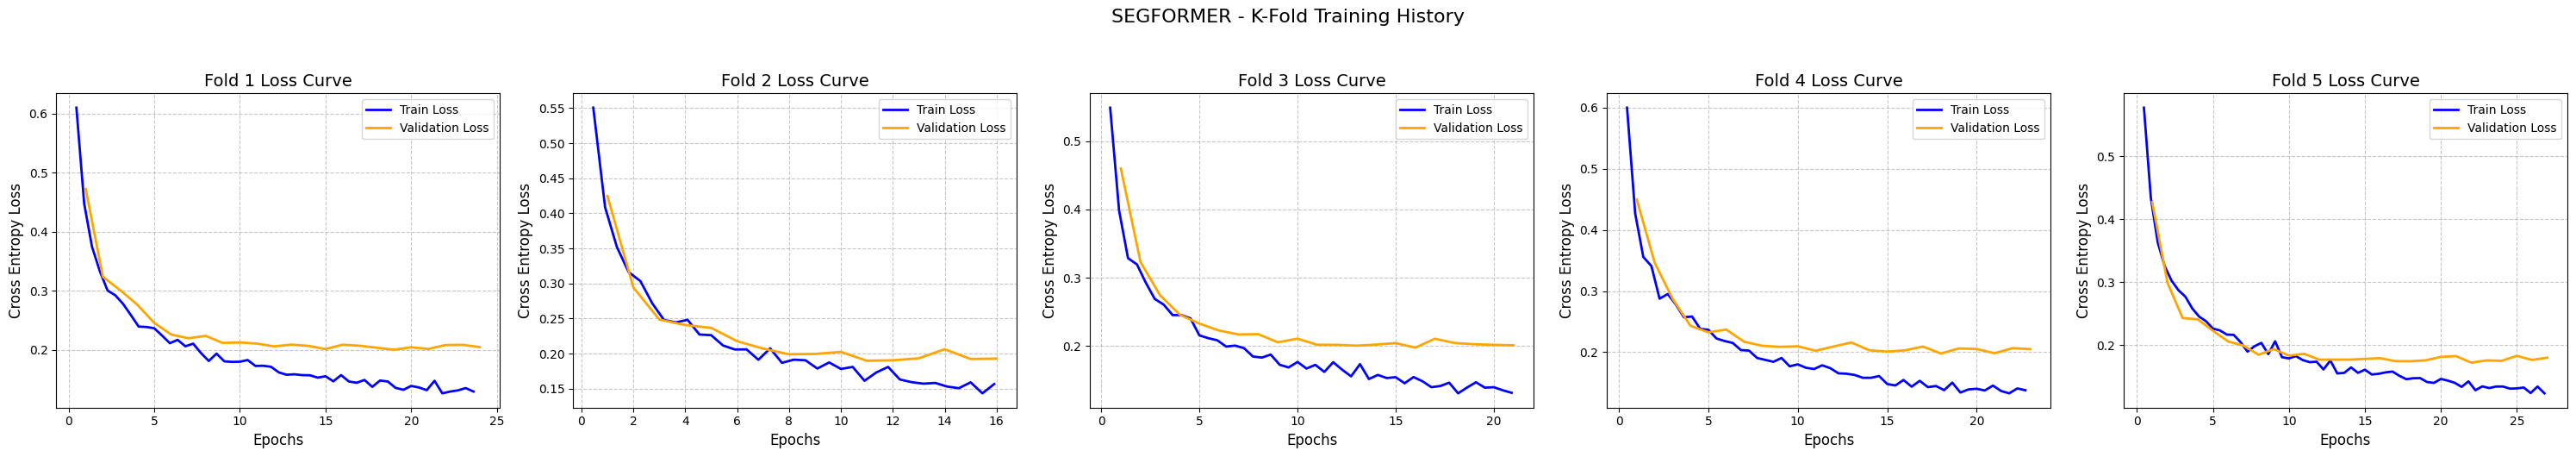

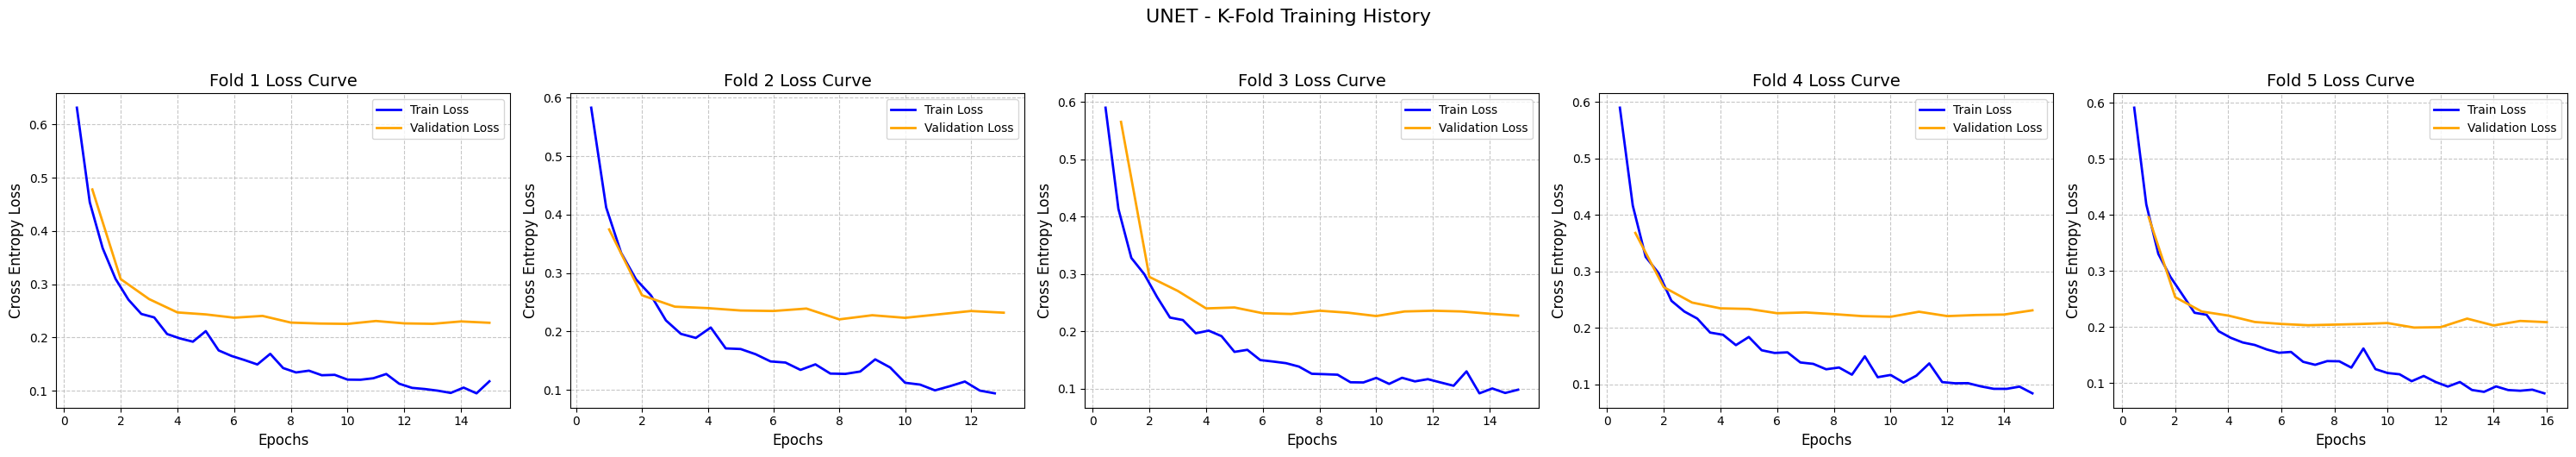

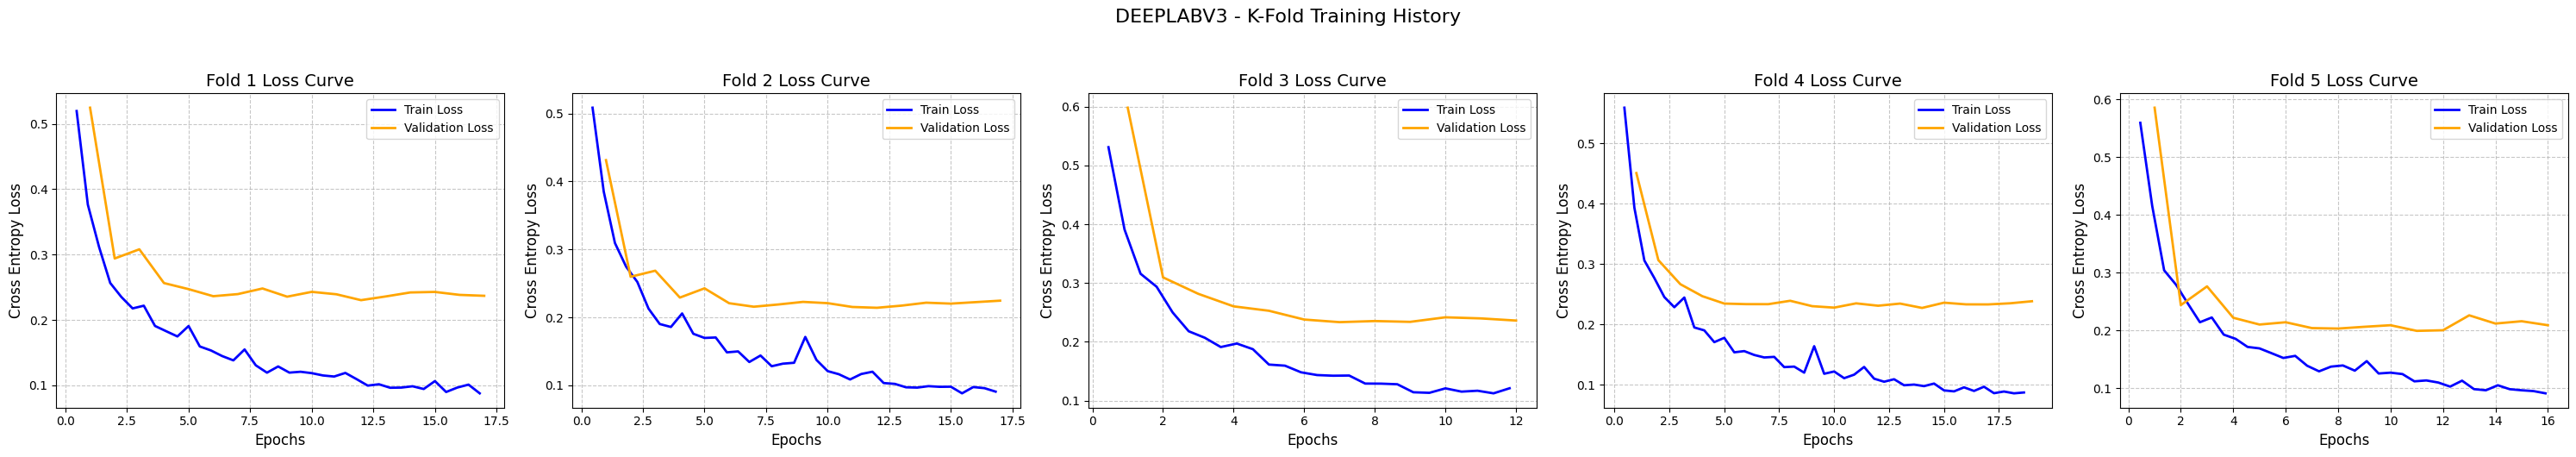

In [ ]:

config_segformer = Config(active_model="segformer", learning_rate=6e-5, train_batch_size=16)
config_unet      = Config(active_model="unet",      learning_rate=1e-4, train_batch_size=16)
config_deeplab   = Config(active_model="deeplabv3", learning_rate=1e-4, train_batch_size=16)
models_to_run = [config_segformer, config_unet, config_deeplab]

for cfg in models_to_run:
    experiment = SegmentationExperiment(cfg)
    experiment.run_k_fold()
    print(f"\n✅ Finished full K-Fold benchmark for {cfg.ACTIVE_MODEL.upper()}\n")